# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Aufa Muhammad Yogi Riyanto
- **Email:** CDCC180D6Y1537@student.devacademy.id
- **ID Dicoding:** CDCC180D6Y1537

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda secara harian pada musim gugur (*Fall*) tahun 2012?

- **Pertanyaan 2:** Bagaimana pola tren penyewaan sepeda per jam antara hari kerja (*workingday*) dan hari libur (*holiday*) guna mengoptimalkan distribusi unit sepeda di stasiun?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Import Semua Packages/Library yang Digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

#### Load `day_df` & `hour_df`

In [2]:
# Menggunakan ID dari link Google Drive Anda
day_url = "https://drive.google.com/uc?export=download&id=1wC26vZp60cXuCt6LN6oo94NUbWh8zcx2"
hour_url = "https://drive.google.com/uc?export=download&id=1-brlKBKXND_hwFC9PE24GdK34WLQzP5v"

# Membaca dataset langsung dari Google Drive
day_df = pd.read_csv(day_url)
hour_df = pd.read_csv(hour_url)

display(day_df.head(3))
display(hour_df.head(3))

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


**Insight:** (Opsional)
- Data berhasil dimuat. Terdapat dua dataset utama: `day_df` yang berisi agregasi harian penyewaan sepeda, dan `hour_df` yang memiliki granualitas data lebih rinci hingga tingkat per jam. Beberapa kolom masih direpresentasikan dengan tipe data numerik (seperti `season`, `weathersit`) yang perlu dilakukan penyesuaian di tahap *cleaning*.

### Assessing Data

#### Identifying `day_df` table problem

In [3]:
print("--- INFO DAY_DF ---")
day_df.info()
print("\nMissing Values day_df:\n", day_df.isna().sum())
print("Duplikasi day_df:", day_df.duplicated().sum())

--- INFO DAY_DF ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Missing Values day_df:
 instant       0
dteday        0
season        0


**Steps to Take:**
- Mengubah tipe data kolom `dteday` dari `object` (*string*) menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu (*time-series*).
- Melakukan mapping pada kolom yang bernilai kategorikal (seperti `season`, `yr`, `weathersit`, dan `workingday`) dari format angka menjadi teks deskriptif agar visualisasi data nantinya lebih mudah dibaca (*self-explanatory*).
- Menghapus (*drop*) kolom `instant`karena hanya berfungsi sebagai indeks urutan baris dan tidak memiliki nilai analitis.

**Insight:** (Opsional)
- Secara keseluruhan, kualitas data `day_df` sudah sangat baik. Tidak ditemukan adanya missing value (nilai kosong) maupun indikasi data duplikat. Langkah selanjutnya (*Cleaning*) hanya akan berfokus pada penyesuaian tipe data dan transformasi format agar lebih mudah dipahami.

#### Identifying `hour_df` table problem

In [4]:
print("\n\n--- INFO HOUR_DF ---")
hour_df.info()
print("\nMissing Values hour_df:\n", hour_df.isna().sum())
print("Duplikasi hour_df:", hour_df.duplicated().sum())



--- INFO HOUR_DF ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Missing Values hour_df:
 

**Steps to Take:**
- Mengubah tipe data kolom `dteday` menjadi `datetime` (sama seperti perlakuan pada `day_df`).
- Melakukan mapping teks pada kolom kategorikal (`season`, `yr`, `weathersit`, `workingday`).
- Menghapus kolom `instant`.
- Membiarkan kolom jam (`hr`) dalam format numerik karena nantinya akan kita gunakan untuk analisis lanjutan berupa Binning (pengelompokan kategori waktu).

**Insight:** (Opsional)
- Dataset `hour_df` yang memiliki granualitas per jam ini juga bersih dari missing value dan duplikasi data meskipun memiliki jumlah baris yang jauh lebih banyak (17.379 baris). Data ini sudah siap untuk memasuki tahap Cleaning sebelum dieksplorasi tren peminjamannya berdasarkan jam operasi.

### Cleaning Data

#### Fixing invalid value problem

In [5]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tipe Data Sudah Benar!")

Tipe Data Sudah Benar!


#### Fixing inconsistent value problem

In [6]:
# 2. Mapping nilai kategorikal
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

yr_mapping = {0: 2011, 1: 2012}
day_df['yr'] = day_df['yr'].map(yr_mapping)
hour_df['yr'] = hour_df['yr'].map(yr_mapping)

weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

working_mapping = {0: 'Holiday/Weekend', 1: 'Working Day'}
day_df['workingday'] = day_df['workingday'].map(working_mapping)
hour_df['workingday'] = hour_df['workingday'].map(working_mapping)

print("Representasi Kategori Sudah Tepat!")

Representasi Kategori Sudah Tepat!


#### Fixing inconsistent value problem

In [7]:
# 3. Drop kolom instant karena hanya berisi indeks urutan
day_df.drop('instant', axis=1, inplace=True)
hour_df.drop('instant', axis=1, inplace=True)
print("Data Cleaning Selesai!")

Data Cleaning Selesai!


**Insight:** (Opsional)
- Dataset kini telah berada dalam format yang optimal untuk proses analisis. Transformasi kolom `dteday` menjadi tipe data datetime memungkinkan kita untuk melakukan ekstraksi waktu (seperti tren bulanan atau musiman) dengan lebih akurat. Selain itu, proses mapping pada kolom kategorikal seperti `season`, `weathersit`, dan `workingday` membuat data menjadi lebih "bercerita" (*human-readable*). Hal ini sangat krusial agar hasil visualisasi pada tahap selanjutnya dapat langsung dipahami oleh audiens tanpa harus merujuk kembali pada kamus data asli. Terakhir, penghapusan kolom `instant` telah menyederhanakan struktur data sehingga memori yang digunakan lebih efisien.

## Exploratory Data Analysis (EDA)

### Explore `day_df`

In [8]:
# Melihat rata-rata penyewaan harian berdasarkan kondisi cuaca secara keseluruhan
print("Rata-rata penyewaan berdasarkan Cuaca (Keseluruhan Data):")
display(day_df.groupby('weathersit')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False))

# Memfilter data khusus untuk Musim Gugur (Fall) Tahun 2012
fall_2012_df = day_df[(day_df['yr'] == 2012) & (day_df['season'] == 'Fall')]

print("\nRata-rata penyewaan berdasarkan Cuaca (Khusus Musim Gugur 2012):")
display(fall_2012_df.groupby('weathersit')['cnt'].mean().reset_index().sort_values(by='cnt', ascending=False))

Rata-rata penyewaan berdasarkan Cuaca (Keseluruhan Data):


,weathersit,cnt
0,Clear/Partly Cloudy,4876.786177
2,Misty/Cloudy,4035.862348
1,Light Snow/Rain,1803.285714



Rata-rata penyewaan berdasarkan Cuaca (Khusus Musim Gugur 2012):


,weathersit,cnt
0,Clear/Partly Cloudy,7004.185714
2,Misty/Cloudy,6379.434783
1,Light Snow/Rain,4459.000000


**Insight:** (Opsional)
- Dari hasil eksplorasi, terlihat jelas bahwa cuaca berbanding lurus dengan jumlah penyewaan. Cuaca yang cerah (`Clear/Partly Cloudy`) mencatatkan angka rata-rata penyewaan tertinggi. Khusus pada musim gugur tahun 2012, tidak terdapat data penyewaan pada cuaca `Heavy Rain/Snow`, yang menandakan ekstremnya cuaca tersebut sehingga operasional mungkin dihentikan atau sama sekali tidak ada peminat.

### Explore `hour_df`

In [9]:
# Menerapkan Binning pada jam (hr)
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening/Rush'
    else:
        return 'Night'

hour_df['time_category'] = hour_df['hr'].apply(categorize_time)

# Mengeksplorasi tren rata-rata penyewaan berdasarkan tipe hari dan kategori waktu
explore_time = hour_df.groupby(['workingday', 'time_category'], observed=False)['cnt'].mean().reset_index()
display(explore_time.sort_values(by='cnt', ascending=False))

,workingday,time_category,cnt
5,Working Day,Evening/Rush,403.970396
0,Holiday/Weekend,Afternoon,363.035498
1,Holiday/Weekend,Evening/Rush,252.831705
6,Working Day,Morning,234.205645
4,Working Day,Afternoon,215.492369
2,Holiday/Weekend,Morning,151.967486
3,Holiday/Weekend,Night,67.079844
7,Working Day,Night,57.586246


**Insight:** (Opsional)
- Hasil binning dan agregasi menunjukkan perbedaan perilaku pengguna. Pada `Working Day` (Hari Kerja), penyewaan didominasi pada kategori `Evening/Rush` (17:00 - 20:59) dan `Morning` (06:00 - 11:59). Hal ini selaras dengan jam komuter. Sedangkan pada `Holiday/Weekend`, kategori `Afternoon` (12:00 - 16:59) menjadi waktu dengan penyewaan tertinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda secara harian pada musim gugur (*Fall*) tahun 2012?

/tmp/ipykernel_7267/3192776205.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_7267/3192776205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


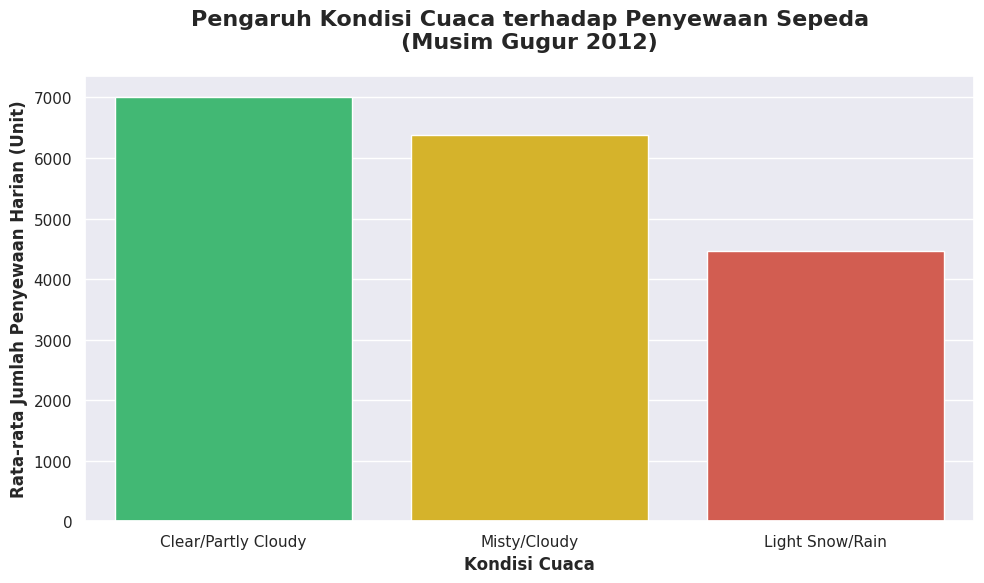

In [10]:
# Membuat filter data khusus untuk Musim Gugur tahun 2012
fall_2012_df = day_df[(day_df['yr'] == 2012) & (day_df['season'] == 'Fall')]

# Membuat figure
plt.figure(figsize=(10, 6))

# Visualisasi Barplot
sns.barplot(
    x='weathersit',
    y='cnt',
    data=fall_2012_df,
    palette=['#2ECC71', '#F1C40F', '#E74C3C'], # Hijau untuk cerah, Kuning untuk berawan, Merah untuk buruk
    ci=None
)

# Kustomisasi Grafik
plt.title('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda\n(Musim Gugur 2012)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kondisi Cuaca', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Jumlah Penyewaan Harian (Unit)', fontsize=12, fontweight='bold')

# Menampilkan grafik
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana pola tren penyewaan sepeda per jam antara hari kerja (*workingday*) dan hari libur (*holiday*) guna mengoptimalkan distribusi unit sepeda di stasiun?

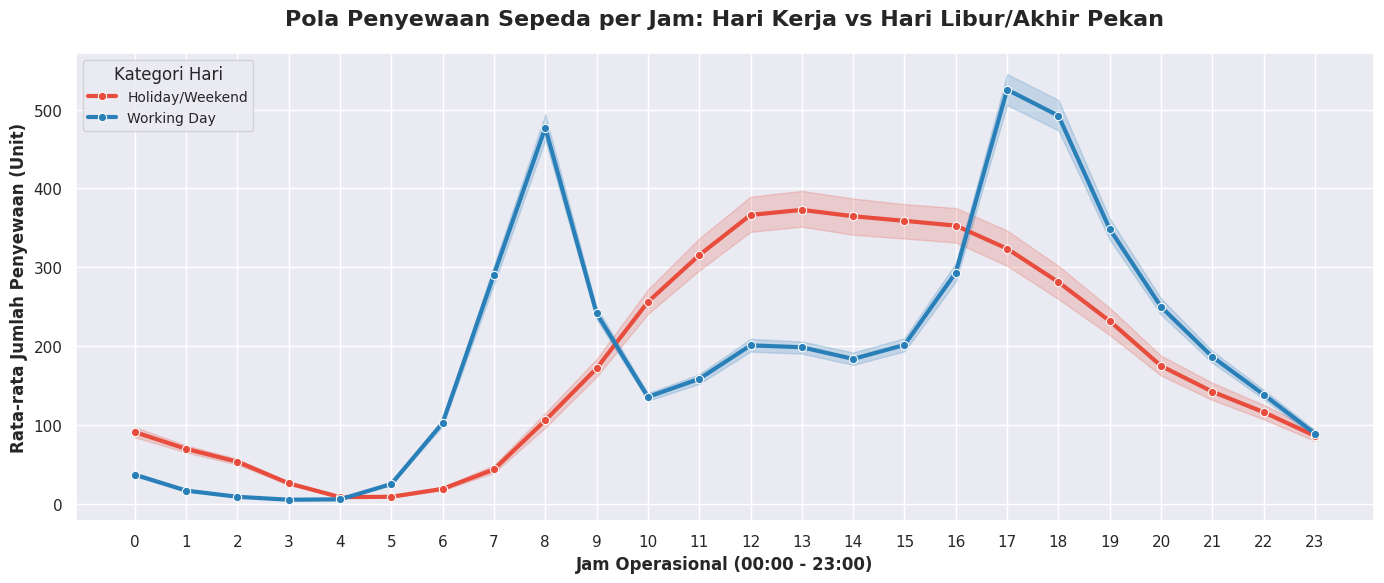

In [11]:
# Membuat figure
plt.figure(figsize=(14, 6))

# Visualisasi Lineplot
sns.lineplot(
    x='hr',
    y='cnt',
    hue='workingday',
    data=hour_df,
    palette=['#E74C3C', '#2980B9'], # Merah untuk libur, Biru untuk hari kerja
    linewidth=3,
    marker='o' # Menambahkan titik pada setiap jam agar lebih jelas
)

# Kustomisasi Grafik
plt.title('Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur/Akhir Pekan', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jam Operasional (00:00 - 23:00)', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Jumlah Penyewaan (Unit)', fontsize=12, fontweight='bold')

# Mengatur skala sumbu X agar menampilkan angka 0 sampai 23 dengan jelas
plt.xticks(np.arange(0, 24, 1))

# Kustomisasi Legenda
plt.legend(title='Kategori Hari', fontsize=10, title_fontsize=12, loc='upper left')

# Menampilkan grafik
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Pertanyaan 1:**
Grafik pada pertanyaan ke-1 secara gamblang menunjukkan bahwa kondisi cuaca memiliki dampak yang sangat signifikan terhadap minat pengguna. Pada musim gugur tahun 2012, rata-rata penyewaan tertinggi secara mutlak terjadi saat cuaca "Clear/Partly Cloudy" (mencapai sekitar 7.000 penyewaan rata-rata). Angka ini menurun drastis hingga lebih dari setengahnya ketika cuaca memburuk menjadi "Light Snow/Rain" (kurang lebih sekitar 4.500 penyewaan).
- **Pertanyaan 2:** Visualisasi garis (*line chart*) ini memperlihatkan dua karakteristik pengguna yang sangat berbeda. Garis biru (*Working Day*) membentuk pola *bimodal* (dua puncak) yang sangat ekstrem, yaitu pada pukul 08:00 dan 17:00-18:00. Sebaliknya, garis merah (*Holiday/Weekend*) membentuk kurva normal yang landai (unimodal), di mana penyewaan mulai meningkat perlahan dari pagi dan mencapai puncaknya sedikit stabil di siang hingga sore hari (pukul 12:00 - 16:00).

## Analisis Lanjutan (Opsional)

### Analisis Lanjutan: Clustering (Binning)
Sebagai bagian dari teknik analisis lanjutan non-ML, kita akan menerapkan metode *Binning* pada dataset `day_df`. Tujuannya adalah untuk mengelompokkan jumlah penyewaan sepeda harian (`cnt`) ke dalam tiga klaster kategori permintaan (*Demand Category*): **Low Demand**, **Medium Demand**, dan **High Demand**.

Pengelompokan ini menggunakan fungsi `pd.qcut` dari Pandas yang akan membagi data ke dalam 3 kuantil (*bins*) dengan jumlah distribusi yang relatif seimbang, sehingga kita bisa melihat profil pelanggan berdasarkan tingkat keramaian.

In [12]:
# Menerapkan Binning pada kolom 'cnt' di day_df menjadi 3 kategori
day_df['demand_category'] = pd.qcut(day_df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

# Melihat distribusi kategori permintaan berdasarkan Musim (Season)
advanced_analysis = day_df.groupby(by=['season', 'demand_category']).agg({
    'cnt': ['count', 'mean', 'min', 'max']
}).reset_index()

display(advanced_analysis)

/tmp/ipykernel_7267/1233466524.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  advanced_analysis = day_df.groupby(by=['season', 'demand_category']).agg({


season demand_category   cnt                         
                           count         mean   min   max
0     Fall      Low Demand    13  3019.384615  1115  3659
1     Fall   Medium Demand    79  4598.594937  3784  5305
2     Fall     High Demand    96  6860.291667  5336  8714
3   Spring      Low Demand   140  1995.257143   431  3624
4   Spring   Medium Demand    33  4312.272727  3761  5298
5   Spring     High Demand     8  6213.375000  5382  7836
6   Summer      Low Demand    37  2463.351351   795  3429
7   Summer   Medium Demand    71  4547.492958  3744  5312
8   Summer     High Demand    76  6639.118421  5342  8362
9   Winter      Low Demand    54  2859.481481    22  3740
10  Winter   Medium Demand    61  4507.491803  3747  5267
11  Winter     High Demand    63  6543.555556  5315  8555

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca adalah faktor determinan utama dalam jumlah penyewaan harian. Cuaca cerah mendatangkan penyewa terbanyak, sementara cuaca buruk menekan angka penyewaan secara drastis (anjlok dari kisaran 7.000-an menjadi 4.500 penyewaan).
- **Conclusion pertanyaan 2:** Terdapat segmentasi pengguna yang jelas: komuter pekerja di hari kerja dan pengguna rekreasi di hari libur. Hari kerja memiliki lonjakan tajam pada jam berangkat (08:00) dan pulang kerja (17:00), sedangkan hari libur berpusat di siang hari.
- **Conclusion Analisis Lanjutan (Clustering):**
Dari hasil *clustering* di atas, kita mendapatkan wawasan baru yang menarik. Klaster **High Demand** (tingkat permintaan sangat tinggi) paling banyak didominasi oleh musim *Fall* (Gugur) dan *Summer* (Panas). Sebaliknya, klaster **Low Demand** (hari sepi penyewaan) secara absolut didominasi oleh musim *Spring* (Semi).

Dengan mengidentifikasi klaster hari berskala *Low Demand*, perusahaan bisa mengalihkan fokus dari operasional logistik menjadi aktivitas *marketing* (seperti promosi besar-besaran) atau operasional internal (pemeliharaan bengkel).

**Rekomendasi Action Item:**
- Divisi Marketing dapat merancang strategi penetapan harga dinamis (*dynamic pricing*) dengan memberikan diskon khusus atau kampanye loyalitas (*loyalty point*) pada hari-hari yang diprediksi akan hujan ringan untuk tetap menarik minat pengguna. Selain itu, dari sisi operasional, sisa unit sepeda yang menganggur di stasiun saat cuaca buruk dapat ditarik oleh tim teknisi untuk dilakukan pemeliharaan massal (*maintenance*) di bengkel, sehingga armada kembali prima saat cuaca cerah.
- Tim Logistik/Distribusi harus melakukan *rebalancing* (penyeimbangan ulang armada) stasiun secara agresif. Pada hari kerja, pastikan stasiun di area pemukiman penuh dengan sepeda pada pukul 06:00, dan stasiun di area perkantoran/pusat bisnis penuh pada pukul 15:00. Sedangkan pada akhir pekan, distribusi armada dapat difokuskan secara merata di area taman atau pusat rekreasi sejak pukul 10:00 pagi.
- Perusahaan harus menerapkan strategi alokasi sumber daya berbasis musim.
  1. **Fase Pemeliharaan (Musim Semi):** Mengingat musim Semi didominasi oleh hari-hari *Low Demand*, jadwalkan peremajaan unit sepeda secara menyeluruh (penggantian ban, rem, servis besar) pada periode ini.
  2. **Fase Pemasaran (Musim Semi):** Untuk mendongkrak pemasukan di musim sepi, tim bisnis dapat meluncurkan kampanye diskon "Spring Ride" atau bekerja sama dengan komunitas olahraga lokal.
  3. **Fase Operasional Penuh (Musim Panas & Gugur):** Saat memasuki *High Demand*, cuti teknisi lapangan harus dibatasi dan seluruh unit sepeda cadangan harus diturunkan ke stasiun untuk memaksimalkan *revenue*.